In [4]:
import pandas as pd
from PIL import Image
import numpy as np
import json
import torchvision
import torch
from os import path
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms.functional as F
from torchvision.models import alexnet, AlexNet_Weights

from tqdm import tqdm

device = "cpu"

In [5]:
# Load movie metadata 
with open("../data/movie_info.json", "r") as f:
    data = json.load(f)

# Get cleaned poster names that map to the images saved with matching names
cleaned_poster_names = [name.split("/")[4] + ".jpg" for name in data.keys()]

In [6]:
len(cleaned_poster_names)

142370

In [7]:
# Load images and map PIL.Image object to the movie name
loaded_images = {}
not_found_poster_count = 0

for poster_name in tqdm(cleaned_poster_names):
    try:
        img_path = path.join("../data/posters/", poster_name)
        with Image.open(img_path) as img:
            loaded_images[poster_name] = img.copy()
    except FileNotFoundError:
        not_found_poster_count += 1

  0%|          | 0/142370 [00:00<?, ?it/s]

100%|██████████| 142370/142370 [03:27<00:00, 686.73it/s]


In [8]:
# Get all unique genres
genre_set = set()
for value in data.values():
    spec_genres = value.get("genre", None)
    if spec_genres:
        for genre in spec_genres:
            genre_set.add(genre)

# Map each genre to a row to use in multi-hot encodings
genre_mapping = {genre:idx for idx, genre in enumerate(genre_set)}

In [9]:
# Create mappings of posters to multi-hot encoded labels (genres)
# Does not include movies with no genres
poster_labels = {}
for key, value in data.items():
    spec_genres = value.get("genre", None)
    multi_hot_blueprint = np.zeros(19, dtype=np.float32)
    if spec_genres:
        for genre in spec_genres:
            multi_hot_blueprint[genre_mapping[genre]] = 1
        poster_labels[key.split("/")[4] + ".jpg"] = torch.from_numpy(multi_hot_blueprint)

In [10]:
poster_labels.get("my-revolution.jpg")

tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0.])

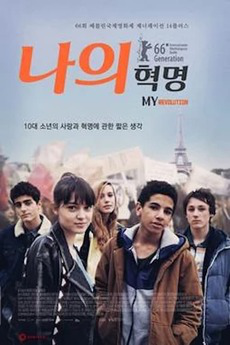

In [12]:
loaded_images.get("my-revolution.jpg")

In [13]:
common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
print(len(common_movies))
print(len(poster_labels.keys()))

124847
126172


In [14]:
weights = AlexNet_Weights.DEFAULT
model = alexnet(weights=weights)

In [15]:
transformer = AlexNet_Weights.DEFAULT.transforms()


In [16]:
class PosterDataset(Dataset):
    def __init__(self, poster_labels, loaded_images):
        self.common_movies = [
            m for m in poster_labels.keys()
            if m in loaded_images.keys()
        ]

        self.x = {m: loaded_images[m] for m in self.common_movies}
        self.y = {m: poster_labels[m] for m in self.common_movies}

        self.transformer = AlexNet_Weights.DEFAULT.transforms()

    def __getitem__(self, idx):
        movie = self.common_movies[idx]

        img = self.x[movie].convert("RGB")
        img = self.transformer(img)

        label = self.y[movie]  # shape: [num_genres]
        return img, label

    def __len__(self):
        return len(self.common_movies)


In [17]:
torchvision.models.AlexNet_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [18]:
dataset = PosterDataset(poster_labels=poster_labels, loaded_images=loaded_images)

In [19]:
# Split dataset into train and validation
generator = torch.Generator().manual_seed(42) # Handles the remainders from the split, used for reproducability
train_dataset, val_dataset, test_dataset = random_split(dataset, (0.8, 0.1, 0.1), generator=generator)

In [20]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_dataloader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=True)

In [21]:
# Load the AlexNet model with pretrained weights
model = torchvision.models.alexnet(weights=torchvision.models.AlexNet_Weights.DEFAULT)

In [22]:
for param in model.features.parameters():
    param.requires_grad = False


In [23]:
num_genres = len(genre_set)

model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=num_genres)

In [26]:
model = model.to(device)

model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [27]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)


In [1]:
MAX_TRAIN_BATCHES = 300    # was: all batches
MAX_VAL_BATCHES   = 100
EPOCHS = 5

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0.0
    train_batches = 0

    for i, (images, targets) in enumerate(train_dataloader):
        if i >= MAX_TRAIN_BATCHES:
            break

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

        if i % 50 == 0:
            print(f"Epoch {epoch} | Train Batch {i} | Loss {loss.item():.4f}")

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for i, (images, targets) in enumerate(val_dataloader):
            if i >= MAX_VAL_BATCHES:
                break

            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            loss = criterion(logits, targets)

            val_loss += loss.item()
            val_batches += 1

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss / train_batches:.4f}, "
        f"val_loss={val_loss / val_batches:.4f}"
    )


NameError: name 'model' is not defined

In [66]:
model.eval()
with torch.no_grad():
    img = transformer(loaded_images["four-for-none.jpg"]).unsqueeze(0).to(device)
    logits = model(img)
    probs = torch.sigmoid(logits)[0]
    preds = (probs > 0.3).int()


In [67]:
preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       dtype=torch.int32)